## Swiggy Sales Analysis

### Importing Libraries

In [299]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

### Loading Data

In [300]:
df=pd.read_excel("c:/Users/tejes/Downloads/swiggy_data.xlsx", engine='calamine')
df.head(5)


,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


### Shape of the Data

In [301]:
df.shape

(197430, 10)

### Data Types

In [302]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

## KPI's

### Total Sales

In [303]:
Total_Sales=round(df['Price (INR)'].sum(),2)
print(f"Total sales :{Total_Sales}","INR")

Total sales :53012505.77 INR


### Average Rating

In [304]:
average_rating=round(df['Rating'].mean(),2)
print(f"Average Rating is :{average_rating}")

Average Rating is :4.34


### Average Order Value

In [305]:
average_order=round(df['Price (INR)'].mean(),2)
print(f"Average Order Value is :{average_order}")

Average Order Value is :268.51


### Ratings Count

In [306]:
rating=df['Rating Count'].sum()
print(f"Total number of customer reviews is :{rating}")

Total number of customer reviews is :5591574


### Total Orders

In [307]:
orders=df['Order Date'].count()
print(f"Total number of orders is :{orders}")

Total number of orders is :197430


In [308]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [309]:
df['Month']=df['Order Date'].dt.month_name()
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Month
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,June
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,April
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,January
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,April
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,March


### Monthly Sales

In [310]:
monthly_revenue=df.groupby('Month')['Price (INR)'].sum()
monthly_revenue

Month
April       6594515.00
August      6791461.90
February    6269105.67
January     6825186.03
July        6650965.51
June        6514183.19
March       6573530.07
May         6793558.40
Name: Price (INR), dtype: float64

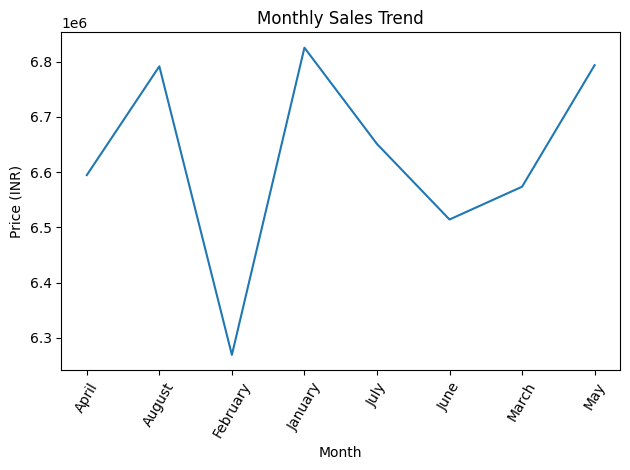

In [311]:
monthly_revenue.plot(kind='line', xlabel='Month', ylabel='Price (INR)',title='Monthly Sales Trend', legend=False)
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### Day Sales

In [312]:
df['Day']=df['Order Date'].dt.day_name()

In [313]:
day_sales=df.groupby("Day")['Price (INR)'].sum().reset_index()
day_sales

,Day,Price (INR)
0,Friday,7579992.78
1,Monday,7445437.01
2,Saturday,7782935.40
3,Sunday,7638004.02
4,Thursday,7664619.49
5,Tuesday,7359414.01
6,Wednesday,7542103.06


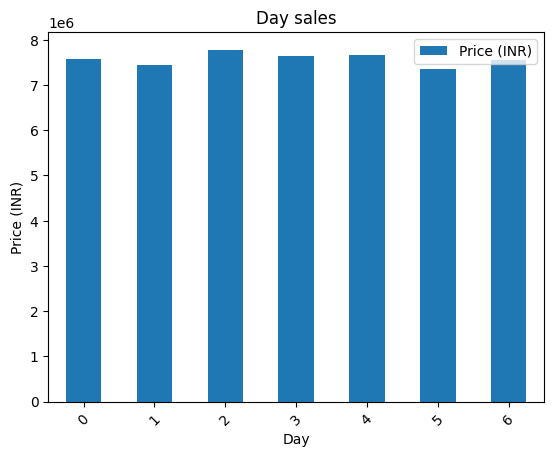

In [314]:
day_sales.plot(kind='bar', xlabel='Day', ylabel='Price (INR)', title='Day sales')
plt.xticks(rotation=45)
plt.show()

### Food Type Sales

In [315]:
non_veg_keywords=['chicken','mutton','fish','prawn','beef','pork','kabab','kebab','non-veg','non veg','kheema']
df['Food Type']=np.where(df['Dish Name'].str.lower().str.contains("|".join(non_veg_keywords),na=False),"Non Veg","Veg")

In [316]:
Food_revenue=df.groupby("Food Type")['Price (INR)'].sum().reset_index()
Food_revenue

,Food Type,Price (INR)
0,Non Veg,16669867.95
1,Veg,36342637.82


In [317]:
fig=px.pie(
    Food_revenue, 
    names='Food Type',
    values='Price (INR)',
    hole=0.5,
    title='Revenue by Food Type'
)
fig.show()

### Sales by State

In [318]:
state=df.groupby('State', as_index=False)['Price (INR)'].sum()
state=state.sort_values(by='Price (INR)', ascending=False)
state



,State,Price (INR)
10,Karnataka,5456798.41
25,Uttar Pradesh,3117359.65
23,Telangana,3021711.62
13,Maharashtra,3015573.35
3,Delhi,2829180.60
5,Gujarat,2817836.02
19,Punjab,2809440.69
27,West Bengal,2662801.76
22,Tamil Nadu,2642594.63
20,Rajasthan,2502932.61


In [319]:
fig=px.bar(
    state,
    x="Price (INR)",
    y="State",
    title="Revenue by State"
)
fig.show()

### Quarterly Performance

In [320]:
df['Quarter']=df['Order Date'].dt.quarter
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count,Month,Day,Food Type,Quarter
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0,June,Sunday,Veg,2
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25,April,Thursday,Veg,2
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48,January,Wednesday,Veg,1
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65,April,Thursday,Veg,2
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0,March,Thursday,Veg,1


In [321]:
quarter_data=(df.groupby('Quarter', as_index=False).agg(
    Quarter=("Price (INR)","sum"),
    Average_ratings=("Rating", "mean"),
    Total_orders=("Order Date","count")
).sort_values('Quarter'))
quarter_data


,Quarter,Average_ratings,Total_orders
2,13442427.41,4.342359,50171
0,19667821.77,4.342643,73096
1,19902256.59,4.340011,74163


### Sales by City

In [322]:
city=df.groupby('City')['Price (INR)'].sum().nlargest(5).sort_values().reset_index()

In [323]:
city

,City,Price (INR)
0,New Delhi,2829180.60
1,Mumbai,3015573.35
2,Hyderabad,3021711.62
3,Lucknow,3117359.65
4,Bengaluru,5456798.41


In [324]:
fig=px.bar(city,
           x='Price (INR)',
           y='City',
           orientation="h",
           color_discrete_sequence=['sky blue'],
           title="Sales by City"
           )

fig.show()

In [325]:
df['week']=df['Order Date'].dt.isocalendar().week
week=df.groupby('week')['Price (INR)'].sum().reset_index()
week

,week,Price (INR)
0,1,1101057.42
1,2,1543434.40
2,3,1512362.20
3,4,1540131.11
4,5,1549636.81
5,6,1517261.95
6,7,1560241.45
7,8,1697992.73
8,9,1491166.47
9,10,1472957.58


In [326]:
fig=px.bar(week.sort_values(by='Price (INR)',ascending=False),
            x='week',
            y='Price (INR)',
            title='Sales by Week'
            )
fig.show()